In [1]:
import pandas as pd 
from matplotlib import rcParams, rcParamsDefault
import matplotlib.pyplot as plt
import seaborn as sns

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}

In [2]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


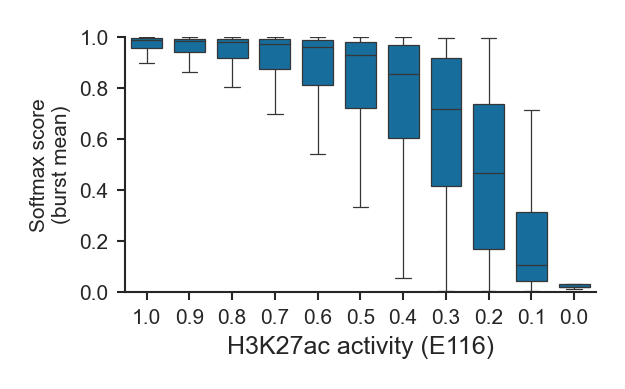

In [3]:
eid = 'E116'
label = 1
keep_mark = 'H3K27ac'

predictions = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_mean.csv")

data = predictions[(predictions['keep_mark']==keep_mark)]


# 设置图形大小（转换厘米到英寸）
fig, ax = plt.subplots(figsize=(5/2.54, 3/2.54), constrained_layout=True)

# 定义 x 轴顺序
order = list(range(10, -1, -1))
xticklabels = [f"{1-i * 0.1:.1f}" for i in order]

# 绘制 boxplot
sns.boxplot(
    data=data[data['mean_label_label'] == label],
    y='mean_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax
)

ax.tick_params(axis='x', labelsize=6,width=0.5)
ax.tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax.set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax.set_ylim(0, 1)
ax.set_xlabel(f"{keep_mark} activity ({eid})",fontsize=6)
ax.set_ylabel("Softmax score\n(burst mean)",fontsize=5)

# 显示图形
plt.show()

In [4]:
eid = 'E118'
# label = 1
keep_mark = 'H3K27ac'
keep_mark = 'H3K27me3'

predictions_mean = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_mean.csv")

data = predictions_mean[(predictions_mean['keep_mark']==keep_mark) & (predictions_mean['mean_label_label'] == 1) & (predictions_mean['perturbation_strength'] == 10)]
expression_gene_ids = list(data['gene_id'])

data = predictions_mean[(predictions_mean['keep_mark']==keep_mark) & (predictions_mean['mean_label_label'] == 0) & (predictions_mean['perturbation_strength'] == 10)]
none_expression_gene_ids = (data['gene_id'])
none_expression_gene_ids

596926    ENSG00000100351
596930    ENSG00000198553
596931    ENSG00000161031
596935    ENSG00000141519
596936    ENSG00000095397
               ...       
610799    ENSG00000237136
610801    ENSG00000101695
610802    ENSG00000109738
610806    ENSG00000066032
610807    ENSG00000255524
Name: gene_id, Length: 6662, dtype: object

In [11]:
eid = 'E116'
label = 1
keep_marks = ['H3K27ac']
masked_marks = ['H3K27ac']
predictions = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_mean.csv")
predictions

,gene_id,mean_label_label,mean_label_score,mean_label_pred,fold,keep_mark,perturbation_strength
0,ENSG00000213977,1,0.038460,0,0,H3K4me1,0
1,ENSG00000067596,1,0.038460,0,0,H3K4me1,0
2,ENSG00000099901,1,0.038460,0,0,H3K4me1,0
3,ENSG00000171936,0,0.038460,0,0,H3K4me1,0
4,ENSG00000100012,0,0.038460,0,0,H3K4me1,0
...,...,...,...,...,...,...,...
1192494,ENSG00000175077,0,0.078837,0,3,H3K9ac,10
1192495,ENSG00000172888,1,0.954670,1,3,H3K9ac,10
1192496,ENSG00000178257,0,0.173250,0,3,H3K9ac,10
1192497,ENSG00000141380,1,0.985997,1,3,H3K9ac,10


KeyError: 'bf_label_label'

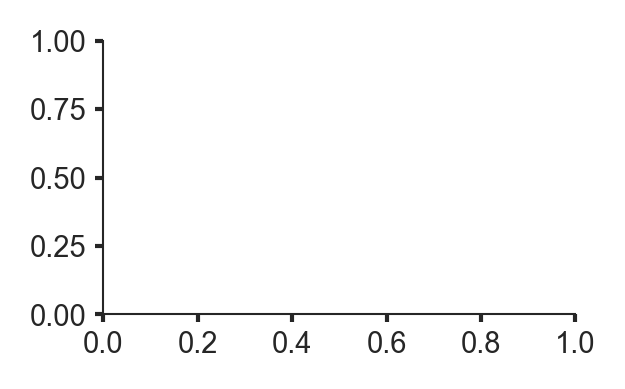

In [12]:
eid = 'E116'
keep_marks = ['H3K27ac']
masked_marks = ['H3K27ac']
predictions_mask = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_keep_{'_'.join(keep_marks)}_masked_{'_'.join(masked_marks)}_predictions_bs_bf_masked_0.csv")
predictions_mask


# 设置图形大小（转换厘米到英寸）
fig, ax = plt.subplots(figsize=(5/2.54, 3/2.54), constrained_layout=True)

# 定义 x 轴顺序
order = list(range(10, -1, -1))
xticklabels = [f"{1-i * 0.1:.1f}" for i in order]

# 绘制 boxplot
sns.boxplot(
    data=predictions_mask[predictions_mask['bf_label_label'] == 0],
    y='bf_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax
)

ax.tick_params(axis='x', labelsize=6,width=0.5)
ax.tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax.set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax.set_ylim(0, 1)
ax.set_xlabel(f"{keep_marks[0]} activity ({eid})",fontsize=6)
ax.set_ylabel("Softmax score\n(burst freq)",fontsize=5)

# 显示图形
plt.show()


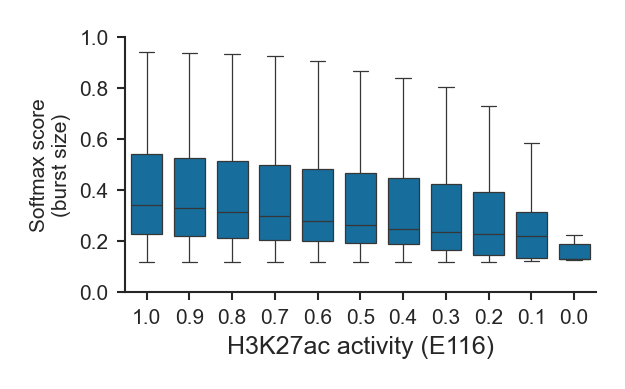

In [139]:
eid = 'E116'
keep_marks = ['H3K27ac']
masked_marks = ['H3K27ac']
predictions_mask = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_keep_{'_'.join(keep_marks)}_masked_{'_'.join(masked_marks)}_predictions_bs_bf_masked_0.csv")
predictions_mask


# 设置图形大小（转换厘米到英寸）
fig, ax = plt.subplots(figsize=(5/2.54, 3/2.54), constrained_layout=True)

# 定义 x 轴顺序
order = list(range(10, -1, -1))
xticklabels = [f"{1-i * 0.1:.1f}" for i in order]

# 绘制 boxplot
sns.boxplot(
    data=predictions_mask[predictions_mask['bs_label_label'] == 0],
    y='bs_label_score',
    x='perturbation_strength',
    order=order,
    gap=0.1,
    width=0.8,
    fliersize=0,
    linewidth=0.3,
    ax=ax
)

ax.tick_params(axis='x', labelsize=6,width=0.5)
ax.tick_params(axis='y', labelsize=5,width=0.5)
# 设置 x 轴刻度
ax.set_xticks(order, labels=xticklabels, fontsize=5)

# 设置 y 轴范围
ax.set_ylim(0, 1)
ax.set_xlabel(f"{keep_marks[0]} activity ({eid})",fontsize=6)
ax.set_ylabel("Softmax score\n(burst size)",fontsize=5)

# 显示图形
plt.show()


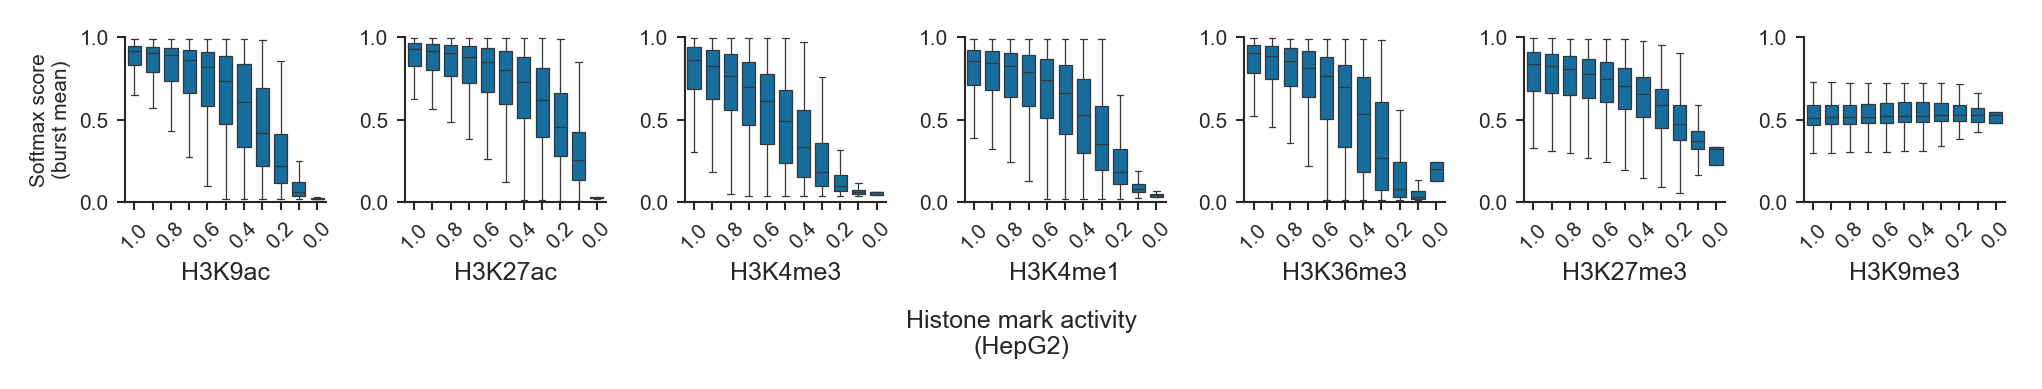

In [7]:
eid = 'E118'
predictions = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_mean.csv")
predictions
fig_order = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
# 设置图形大小（转换厘米到英寸）
fig, ax = plt.subplots(1,7,figsize=(17/2.54, 3/2.54), constrained_layout=True)
label = 1
# 定义 x 轴顺序
order = list(range(10, -1, -1))
xticklabels = [f"{1-i * 0.1:.1f}" if i % 2 == 0 else '' for i in order]

for _idx, keep_mark in enumerate(fig_order):
    data = predictions[predictions['keep_mark'] == keep_mark]
# 绘制 boxplot
    sns.boxplot(
        data=data[data['mean_label_label'] == label],
        y='mean_label_score',
        x='perturbation_strength',
        order=order,
        gap=0.1,
        width=0.8,
        fliersize=0,
        linewidth=0.3,
        ax=ax[_idx]
    )

    ax[_idx].tick_params(axis='x', labelsize=6,width=0.5)
    ax[_idx].tick_params(axis='y', labelsize=5,width=0.5)
    # 设置 x 轴刻度
    ax[_idx].set_xticks(order, labels=xticklabels, fontsize=5,rotation=45)
    # 设置 y 轴范围
    ax[_idx].set_ylim(0, 1)   
    ax[_idx].set_xlabel(f"{keep_mark}",fontsize=6)
    if _idx == 0:
        ax[_idx].set_ylabel("Softmax score\n(burst mean)",fontsize=5)
    else:
        ax[_idx].set_ylabel("",fontsize=5)

fig.supxlabel(f"Histone mark activity\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)

# plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure5C_{EIDS_TO_CELLTYPES[eid]}_{label}.eps', format='eps', bbox_inches='tight')

plt.show()

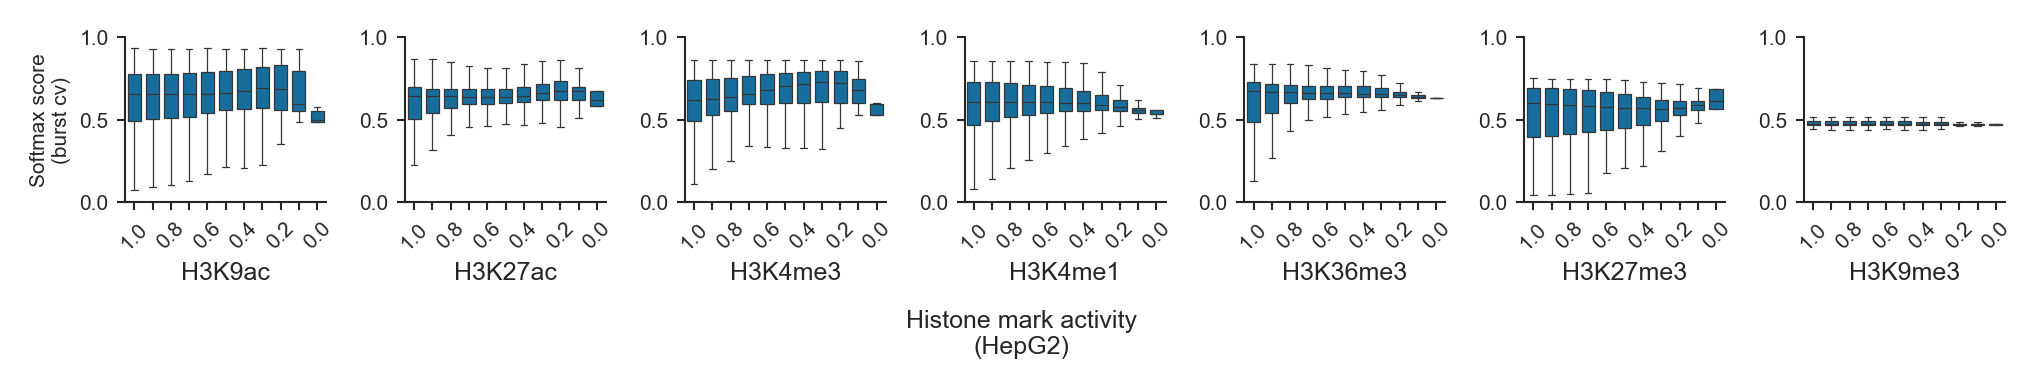

In [8]:
eid = 'E118'
predictions = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_cv.csv")
predictions
fig_order = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
label = 1

# 设置图形大小（转换厘米到英寸）
fig, ax = plt.subplots(1,7,figsize=(17/2.54, 3/2.54), constrained_layout=True)

# 定义 x 轴顺序
order = list(range(10, -1, -1))
xticklabels = [f"{1-i * 0.1:.1f}" if i % 2 == 0 else '' for i in order]

for _idx, keep_mark in enumerate(fig_order):
    data = predictions[predictions['keep_mark'] == keep_mark]
# 绘制 boxplot
    sns.boxplot(
        data=data[data['cv_label_label'] == label],
        # data = data[data['gene_id'].isin(none_expression_gene_ids)],
        y='cv_label_score',
        x='perturbation_strength',
        order=order,
        gap=0.1,
        width=0.8,
        fliersize=0,
        linewidth=0.3,
        ax=ax[_idx]
    )

    ax[_idx].tick_params(axis='x', labelsize=6,width=0.5)
    ax[_idx].tick_params(axis='y', labelsize=5,width=0.5)
    # 设置 x 轴刻度
    ax[_idx].set_xticks(order, labels=xticklabels, fontsize=5,rotation=45)
    # 设置 y 轴范围
    ax[_idx].set_ylim(0, 1)   
    ax[_idx].set_xlabel(f"{keep_mark}",fontsize=6)
    if _idx == 0:
        ax[_idx].set_ylabel("Softmax score\n(burst cv)",fontsize=5)
    else:
        ax[_idx].set_ylabel("",fontsize=5)

fig.supxlabel(f"Histone mark activity\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
# plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure5D_{EIDS_TO_CELLTYPES[eid]}_{label}.eps', format='eps', bbox_inches='tight')
# 
plt.show()

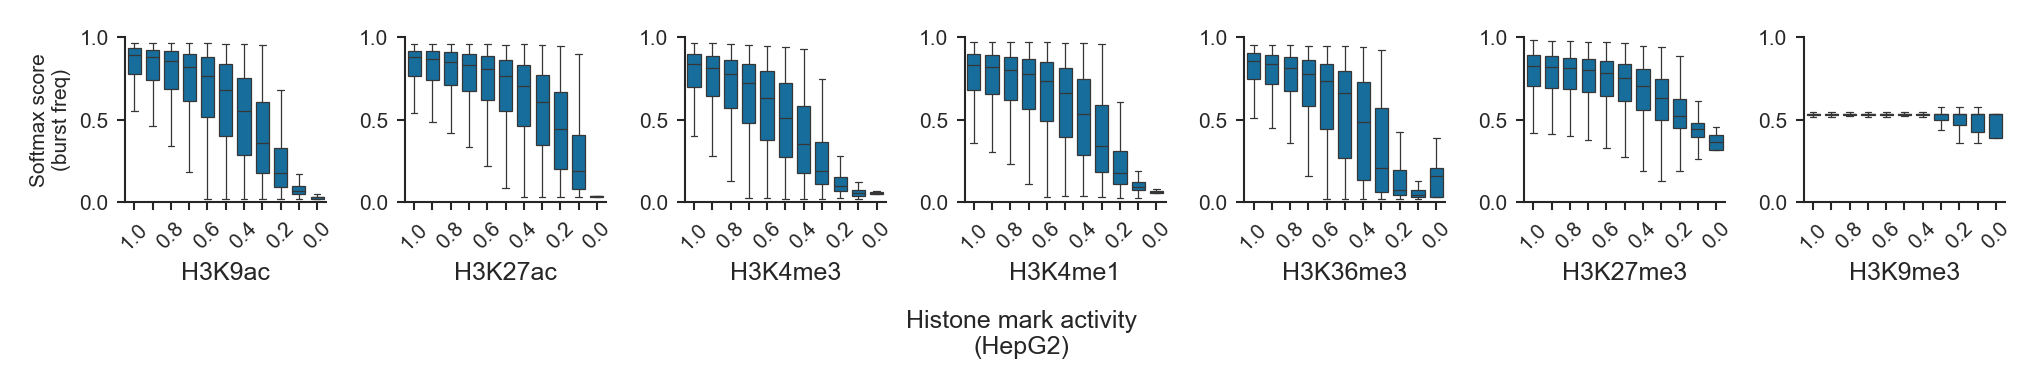

In [9]:
eid = 'E118'
predictions = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_bs_bf.csv")
predictions
fig_order = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
# 设置图形大小（转换厘米到英寸）
fig, ax = plt.subplots(1,7,figsize=(17/2.54, 3/2.54), constrained_layout=True)
label = 1

# 定义 x 轴顺序
order = list(range(10, -1, -1))
xticklabels = [f"{1-i * 0.1:.1f}" if i % 2 == 0 else '' for i in order]

for _idx, keep_mark in enumerate(fig_order):
    data = predictions[predictions['keep_mark'] == keep_mark]
# 绘制 boxplot
    sns.boxplot(
        data=data[data['bf_label_label'] == label],
        # data = data[data['gene_id'].isin(expression_gene_ids)],

        y='bf_label_score',
        x='perturbation_strength',
        order=order,
        gap=0.1,
        width=0.8,
        fliersize=0,
        linewidth=0.3,
        ax=ax[_idx]
    )

    ax[_idx].tick_params(axis='x', labelsize=6,width=0.5)
    ax[_idx].tick_params(axis='y', labelsize=5,width=0.5)
    # 设置 x 轴刻度
    ax[_idx].set_xticks(order, labels=xticklabels, fontsize=5,rotation=45)
    # 设置 y 轴范围
    ax[_idx].set_ylim(0, 1)   
    ax[_idx].set_xlabel(f"{keep_mark}",fontsize=6)
    if _idx == 0:
        ax[_idx].set_ylabel("Softmax score\n(burst freq)",fontsize=5)
    else:
        ax[_idx].set_ylabel("",fontsize=5)

fig.supxlabel(f"Histone mark activity\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure5E_{EIDS_TO_CELLTYPES[eid]}_{label}.eps', format='eps', bbox_inches='tight')

plt.show()

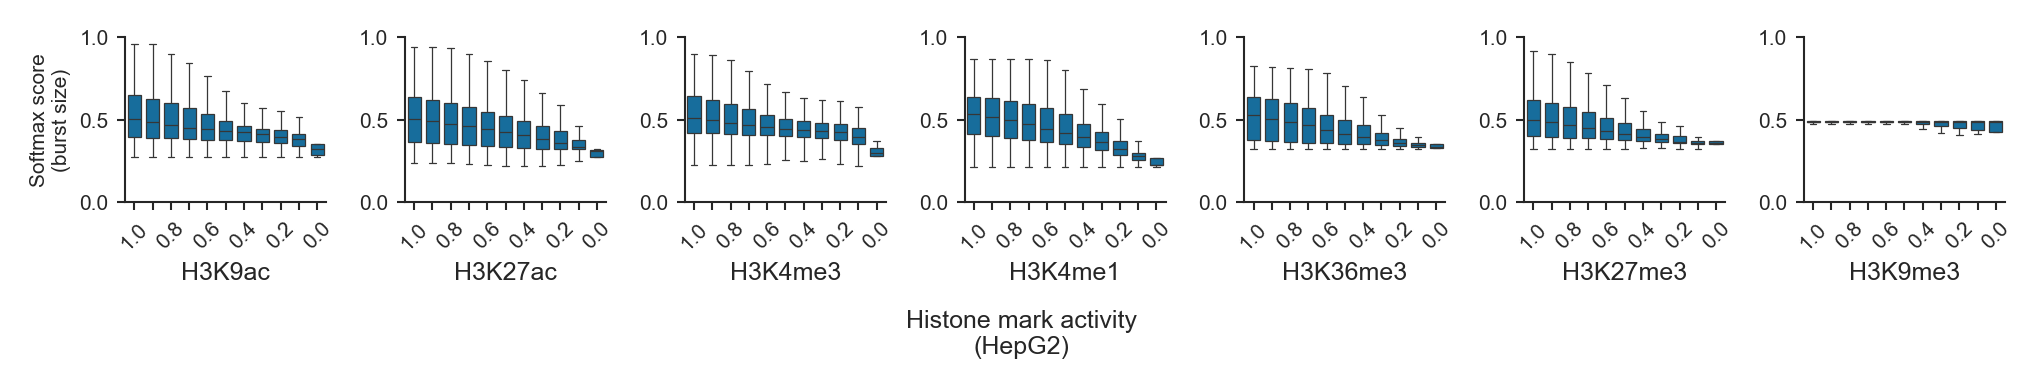

In [10]:
eid = 'E118'
predictions = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_predictions_bs_bf.csv")
predictions
fig_order = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
# 设置图形大小（转换厘米到英寸）
fig, ax = plt.subplots(1,7,figsize=(17/2.54, 3/2.54), constrained_layout=True)
label = 1

# 定义 x 轴顺序
order = list(range(10, -1, -1))
xticklabels = [f"{1-i * 0.1:.1f}" if i % 2 == 0 else '' for i in order]

for _idx, keep_mark in enumerate(fig_order):
    data = predictions[predictions['keep_mark'] == keep_mark]
# 绘制 boxplot
    sns.boxplot(
        data=data[data['bs_label_label'] == label],
        y='bs_label_score',
        x='perturbation_strength',
        order=order,
        gap=0.1,
        width=0.8,
        fliersize=0,
        linewidth=0.3,
        ax=ax[_idx]
    )
    

    ax[_idx].tick_params(axis='x', labelsize=6,width=0.5)
    ax[_idx].tick_params(axis='y', labelsize=5,width=0.5)
    # 设置 x 轴刻度
    ax[_idx].set_xticks(order, labels=xticklabels, fontsize=5,rotation=45)
    # 设置 y 轴范围
    ax[_idx].set_ylim(0, 1)   
    ax[_idx].set_xlabel(f"{keep_mark}",fontsize=6)
    if _idx == 0:
        ax[_idx].set_ylabel("Softmax score\n(burst size)",fontsize=5)
    else:
        ax[_idx].set_ylabel("",fontsize=5)

fig.supxlabel(f"Histone mark activity\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
plt.savefig(f'extra/datasets/benchmark/Promoterformer/figures/Figure5F_{EIDS_TO_CELLTYPES[eid]}_{label}.eps', format='eps', bbox_inches='tight')

plt.show()

<Axes: xlabel='perturbation_region', ylabel='mean_label_score'>

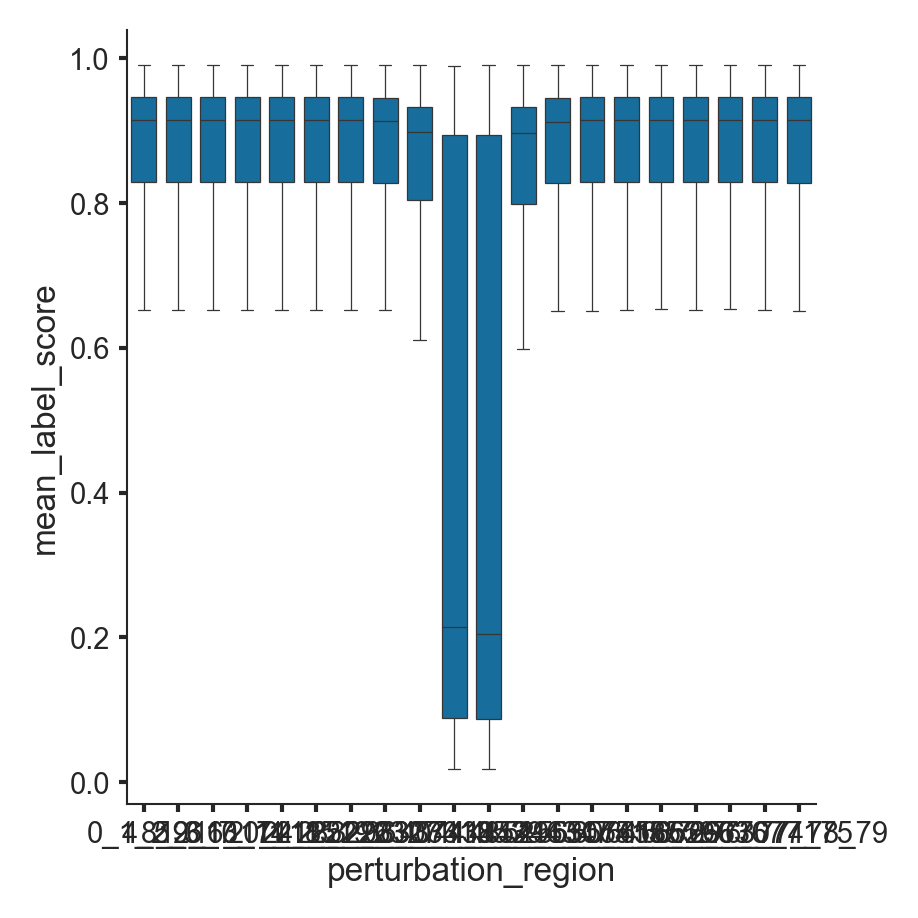

In [9]:
eid = 'E118'
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_region_predictions_mean.csv")
# data
keep_mark = 'H3K9ac'
label = 1
data = data[((data['keep_mark']==keep_mark)) & (data['mean_label_label'] == label)]
high_mean_gene_ids = list(data['gene_id'].unique())
sns.boxplot(
        data=data,
        # data = data[data['gene_id'].isin(expression_gene_ids)],
        y='mean_label_score',
        x='perturbation_region',
        # order=order,
        gap=0.1,
        width=0.8,
        fliersize=0,
        linewidth=0.3,
        # ax=ax[_idx]
    )

<Axes: xlabel='perturbation_region', ylabel='mean_label_score'>

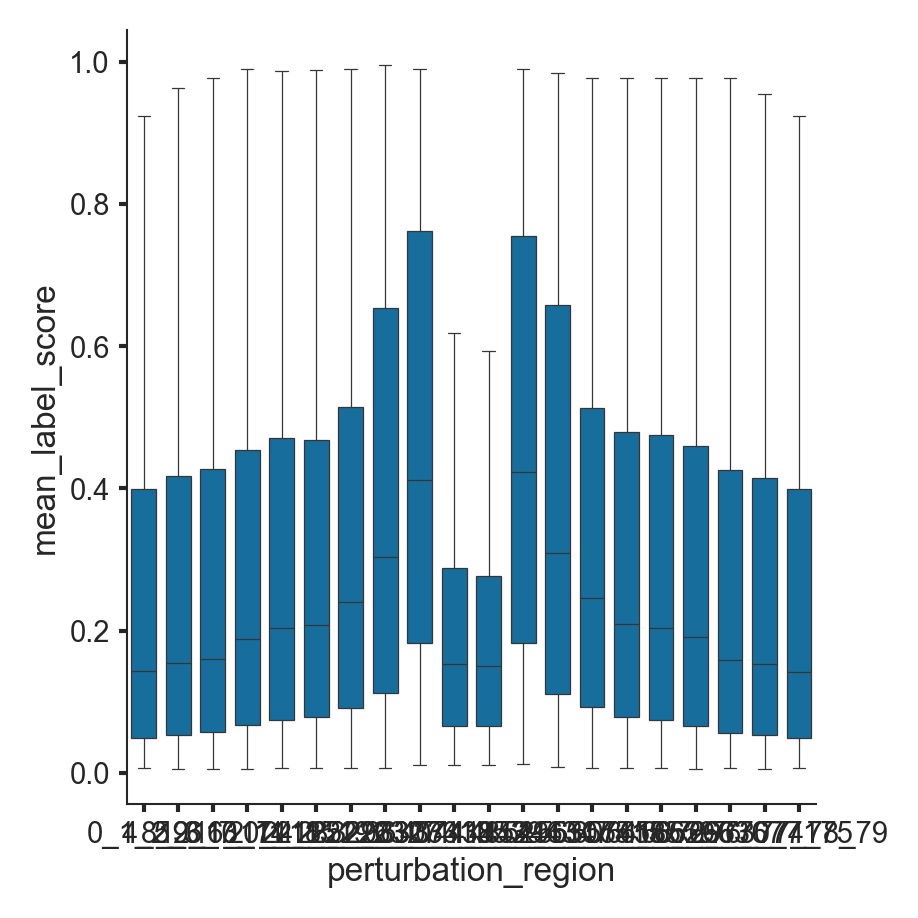

In [10]:
eid = 'E118'
data = pd.read_csv(f"extra/datasets/benchmark/Promoterformer/results/{eid}_perturbation_region_predictions_mean.csv")
# data
keep_mark = 'H3K27me3'
label = 0
data = data[((data['keep_mark']==keep_mark)) & (data['mean_label_label'] == label)]
high_mean_gene_ids = list(data['gene_id'].unique())
sns.boxplot(
        data=data,
        # data = data[data['gene_id'].isin(expression_gene_ids)],
        y='mean_label_score',
        x='perturbation_region',
        # order=order,
        gap=0.1,
        width=0.8,
        fliersize=0,
        linewidth=0.3,
        # ax=ax[_idx]
    )

In [ ]:
keep_mark = 'H3K9ac'
label = 1
data = data[((data['keep_mark']==keep_mark)) & (data['mean_label_label'] == label)]
high_mean_gene_ids = list(data['gene_id'].unique())
sns.boxplot(
        data=data,
        # data = data[data['gene_id'].isin(expression_gene_ids)],
        y='mean_label_score',
        x='perturbation_region',
        # order=order,
        gap=0.1,
        width=0.8,
        fliersize=0,
        linewidth=0.3,
        # ax=ax[_idx]
    )